<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Unidad4/Practica_4_Segmentaci%C3%B3n_de_prestatarios_con_K_Meansipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [133]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
prestamos = pd.read_csv("/content/lending_club_2007_2011_6_states (3).csv")
prestamos.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN


In [134]:
le = LabelEncoder()
prestamos["grade_code"] = le.fit_transform(prestamos["grade"])
prestamos["purpose_code"] = le.fit_transform(prestamos["purpose"])

In [135]:
features = ['funded_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'grade_code', 'purpose_code']
data = prestamos[features].dropna()
data.head()

,funded_amnt,int_rate,annual_inc,dti,revol_util,grade_code,purpose_code
0,2400,15.96,12252.0,8.72,98.5,2,11
1,10000,13.49,49200.0,20.00,21.0,2,9
2,3000,18.64,48000.0,5.35,87.5,4,0
3,5600,21.28,40000.0,5.55,32.6,5,11
4,5375,12.69,15000.0,18.08,36.5,1,9


In [136]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(data)

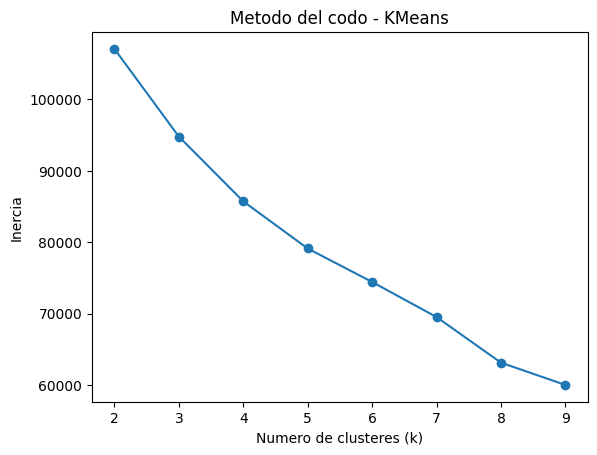

In [137]:
inertia=[]
K= range (2, 10)
for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(x_scaled)
  inertia.append(kmeans.inertia_)
plt.plot(K, inertia, marker='o')
plt.title("Metodo del codo - KMeans")
plt.xlabel("Numero de clusteres (k)")
plt.ylabel("Inercia")
plt.show()

In [138]:
from sklearn import cluster
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
data["cluster"] = clusters

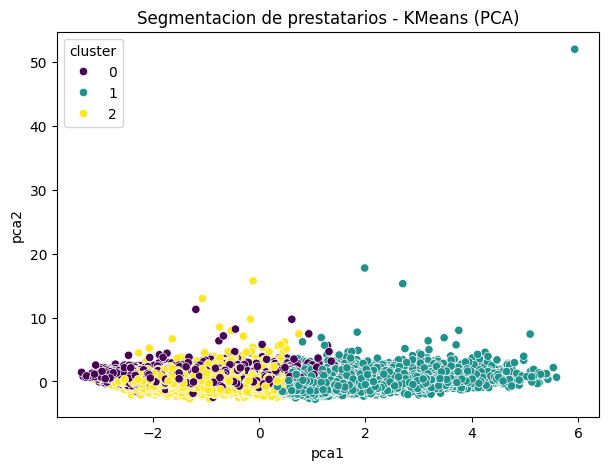

In [139]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_scaled)
data["pca1"], data["pca2"] = pca_result[:,0], pca_result[:,1]
plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.title("Segmentacion de prestatarios - KMeans (PCA)")
plt.show()

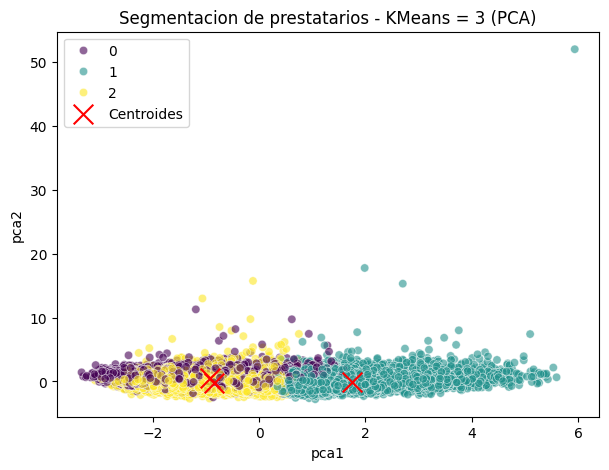

In [140]:
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis", alpha=0.6)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="x", label="Centroides")
plt.title("Segmentacion de prestatarios - KMeans = 3 (PCA)")
plt.legend()
plt.show()

In [141]:
resumen_cluster = data.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", resumen_cluster)


Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_code  \
cluster                                                                     
0            8093.14     10.88    65304.21  10.50       36.14        1.12   
1           14030.72     15.91    77513.48  14.63       69.60        3.08   
2           10270.12      9.79    69009.10  12.99       40.61        0.72   

         purpose_code  
cluster                
0                9.26  
1                2.99  
2                2.05  


In [142]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(x_scaled, clusters)
print("Silhouette score con k=3:", sil_score)
print("Inercia con k = 3:", kmeans.inertia_)

Silhouette score con k=3: 0.20467397458390574
Inercia con k = 3: 94780.8833536469


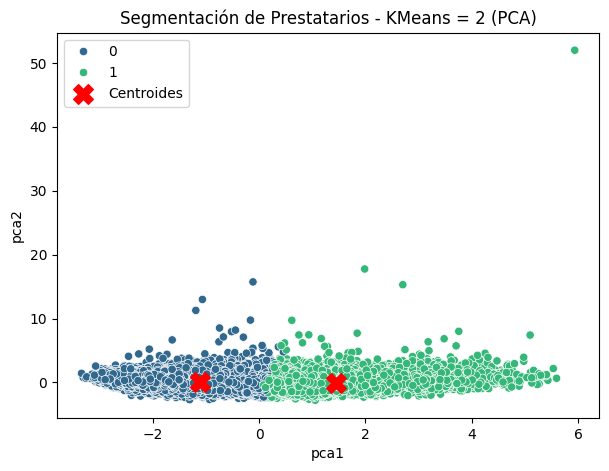

In [143]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
data["cluster"] = clusters
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 2 (PCA)")
plt.legend()
plt.show()

In [144]:
summary = data.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", summary)


Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_code  \
cluster                                                                     
0            9205.83      9.61    67150.04  11.79       35.54        0.67   
1           13486.87     15.29    76173.28  14.59       67.39        2.80   

         purpose_code  
cluster                
0                4.25  
1                3.47  


In [145]:
sil_score = silhouette_score(x_scaled, clusters)
print("Silhouette score con k = 2:", sil_score)
print("Inercia con k = 2", kmeans.inertia_)

Silhouette score con k = 2: 0.22799112031609506
Inercia con k = 2 107052.86787710573


In [146]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
data["cluster"] = clusters

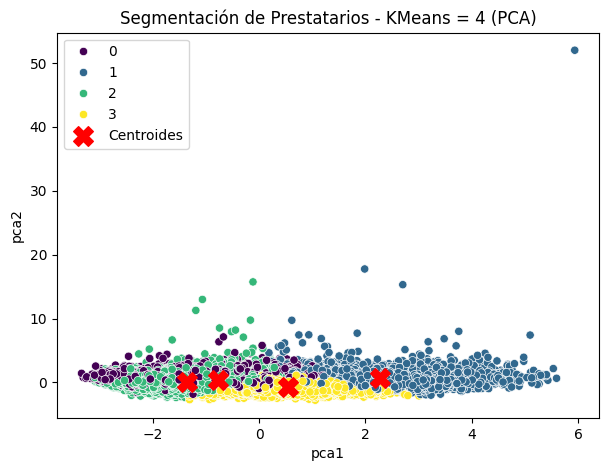

In [147]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_scaled)
data["pca1"], data["pca2"] = pca_result[:,0], pca_result[:,1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 4 (PCA)")
plt.legend()
plt.show()

In [148]:
summary = data.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", summary)


Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_code  \
cluster                                                                     
0            8060.17     11.25    63845.02  10.95       38.73        1.24   
1           18834.01     17.13    97405.86  13.41       65.57        3.62   
2           10166.51      8.84    72657.44  10.80       28.64        0.46   
3            9411.70     12.93    59112.61  16.20       67.13        1.79   

         purpose_code  
cluster                
0                9.67  
1                3.37  
2                2.38  
3                2.21  


In [149]:
sil_score = silhouette_score(x_scaled, clusters)
print("Silhouette score con k = 4:", sil_score)
print("Inercia con k = 4:", kmeans.inertia_)

Silhouette score con k = 4: 0.17565179006763865
Inercia con k = 4: 85725.27376621244


In [151]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
resultados = []
K = range(2, 13)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(x_scaled, labels)
    calinski = calinski_harabasz_score(x_scaled, labels)
    davies = davies_bouldin_score(x_scaled, labels)
    resultados.append({
        "k": k,
        "inercia": inertia,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })
df_resultados = pd.DataFrame(resultados)
df_resultados

,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,107052.867877,0.227991,5976.291666,1.640148
1,3,94780.883354,0.204674,4662.267598,1.663882
2,4,85725.273766,0.175652,4136.528224,1.636573
3,5,79128.698624,0.178546,3775.237621,1.471146
4,6,74443.400268,0.174121,3460.411996,1.508968
5,7,69538.819059,0.169206,3320.601764,1.472366
6,8,63154.958265,0.171385,3420.876252,1.358803
7,9,60038.643832,0.163440,3277.472499,1.367625
8,10,57920.369712,0.159971,3100.465474,1.430076
9,11,55578.489720,0.157743,2991.602367,1.414868


In [152]:
df_norm = df_resultados.copy()
df_norm["rank"] = (
    df_norm["silhouette"].rank(ascending=False) +
    df_norm["calinski_harabasz"].rank(ascending=False) +
    df_norm["davies_bouldin"].rank(ascending=True) +
    df_norm["inercia"].rank(ascending=True)
)
k_optimo = df_norm.sort_values("rank").iloc[0]["k"]
print("K óptimo según combinación de métricas:", k_optimo)

K óptimo según combinación de métricas: 8.0


In [154]:
kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
data["cluster"] = clusters

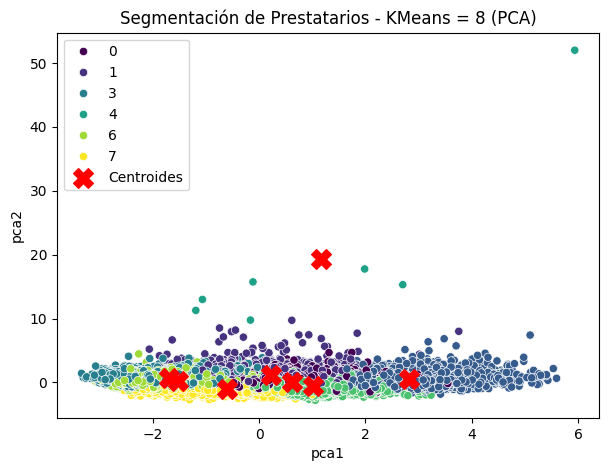

In [155]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(x_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 8 (PCA)")
plt.legend()
plt.show()

In [156]:
summary = data.groupby("cluster")[features].mean().round(2)
print("\nPromedios por clúster:\n", summary)



Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_code  \
cluster                                                                     
0            7719.71     14.30    63860.21  13.18       63.69        2.39   
1           22000.38     12.03   115389.79  11.34       38.88        1.40   
2           20833.23     18.15    93222.44  15.23       69.93        4.07   
3            7697.58      9.19    62247.48   8.87       21.99        0.56   
4            7910.71      9.73  2223112.00   1.71       44.66        0.86   
5            8900.79     14.40    60108.33  13.59       71.04        2.42   
6            8160.71      8.80    67247.83   7.78       27.96        0.46   
7            9028.90      9.89    56071.52  19.65       49.63        0.73   

         purpose_code  
cluster                
0                9.54  
1                2.94  
2                2.77  
3                9.05  
4                3.71  
5                1.90  
6           

In [157]:
sil_score = silhouette_score(x_scaled, clusters)
print("Silhouette score con k = 8:", sil_score)
print("Inercia con k = 8:", kmeans.inertia_)

Silhouette score con k = 8: 0.17138540326724153
Inercia con k = 8: 63154.958264750465


In [161]:
prestamos_df = prestamos.copy()
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
data["cluster"] = clusters
prestamos_df = prestamos_df.loc[data.index]
prestamos_df["cluster"] = clusters
prestamos_df["cluster"].value_counts()
prestamos_df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,grade_code,purpose_code,cluster
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,0.0,0.0,0.0,N,Cash,N,NaN,2,11,1
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,0.0,0.0,0.0,N,Cash,N,NaN,2,9,0
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,0.0,0.0,0.0,N,Cash,N,NaN,4,0,1
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,0.0,0.0,0.0,N,Cash,N,NaN,5,11,1
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,0.0,0.0,0.0,N,Cash,N,NaN,1,9,0
